# Redis Environment Dataset

## Exploratory Data Analysis

### Import libraries

In [253]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.colors import LogNorm
import seaborn as sns

### Loading the data

In [254]:
df = pd.read_csv("redis_gym_observation_corrected.csv")

In [255]:
df.head()

,date,redis-leader_num_pods,redis-leader_desired_replicas,redis-leader_cpu_usage,redis-leader_mem_usage,redis-leader_traffic_in,redis-leader_traffic_out,redis-leader_latency,redis-follower_num_pods,redis-follower_desired_replicas,redis-follower_cpu_usage,redis-follower_mem_usage,redis-follower_traffic_in,redis-follower_traffic_out,redis-follower_latency,redis-leader_cpu_predictions
0,2022-09-10 05:40:37,1.0,2.0,372.0,0.0,633.0,3914.0,0.03,1.0,1.0,73.0,6.7,225.0,48.0,0.03,562.368844
1,2022-09-10 05:40:38,1.0,2.0,372.0,0.0,633.0,3914.0,0.03,1.0,1.0,73.0,6.7,225.0,48.0,0.03,524.295075
2,2022-09-10 05:40:39,1.0,2.0,372.0,0.0,633.0,3914.0,0.03,1.0,1.0,73.0,6.7,225.0,48.0,0.03,493.836060
3,2022-09-10 05:40:40,1.0,2.0,372.0,0.0,633.0,3914.0,0.03,8.0,1.0,73.0,6.7,225.0,48.0,0.03,469.468848
4,2022-09-10 05:40:41,1.0,2.0,372.0,0.0,633.0,3914.0,0.03,5.0,1.0,73.0,6.7,225.0,48.0,0.03,449.975078


### Data Exploration

In [256]:
print(f"Dataset shape: {df.shape}")
print(f"Dataset columns names and types:")
df.info()

Dataset shape: (157965, 16)
Dataset columns names and types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157965 entries, 0 to 157964
Data columns (total 16 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   date                             157965 non-null  object 
 1   redis-leader_num_pods            157965 non-null  float64
 2   redis-leader_desired_replicas    157965 non-null  float64
 3   redis-leader_cpu_usage           157965 non-null  float64
 4   redis-leader_mem_usage           157965 non-null  float64
 5   redis-leader_traffic_in          157965 non-null  float64
 6   redis-leader_traffic_out         157965 non-null  float64
 7   redis-leader_latency             157965 non-null  float64
 8   redis-follower_num_pods          157965 non-null  float64
 9   redis-follower_desired_replicas  157965 non-null  float64
 10  redis-follower_cpu_usage         157965 non-null  float64
 11  redi

In [257]:
# Convert date to datetime objects
df['date'] = pd.to_datetime(df['date'])
df_time = df.set_index('date')

print(f"Data spans from {df_time.index.min()} to {df_time.index.max()}")

Data spans from 2022-09-10 05:40:37 to 2022-09-12 01:33:21


In [258]:
print("Missing values:")
df.isna().sum()

Missing values:


,0
date,0
redis-leader_num_pods,0
redis-leader_desired_replicas,0
redis-leader_cpu_usage,0
redis-leader_mem_usage,0
redis-leader_traffic_in,0
redis-leader_traffic_out,0
redis-leader_latency,0
redis-follower_num_pods,0
redis-follower_desired_replicas,0


In [259]:
df.describe()

,date,redis-leader_num_pods,redis-leader_desired_replicas,redis-leader_cpu_usage,redis-leader_mem_usage,redis-leader_traffic_in,redis-leader_traffic_out,redis-leader_latency,redis-follower_num_pods,redis-follower_desired_replicas,redis-follower_cpu_usage,redis-follower_mem_usage,redis-follower_traffic_in,redis-follower_traffic_out,redis-follower_latency,redis-leader_cpu_predictions
count,157965,157965.000000,157965.000000,157965.000000,157965.000000,157965.000000,157965.000000,1.579650e+05,157965.000000,157965.000000,157965.000000,157965.000000,157965.000000,157965.000000,1.579650e+05,157965.000000
mean,2022-09-11 03:36:59.000000512,4.693375,3.567911,609.961055,5.428032,761.067116,4198.888045,1.307782e+04,2.050980,1.075675,43.055721,5.271882,81.007926,21.679328,1.307782e+04,609.964461
min,2022-09-10 05:40:37,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000e+00,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000e+00,3.000413
25%,2022-09-10 16:38:48,4.000000,3.000000,499.000000,0.800000,578.000000,3098.000000,1.900000e-02,1.000000,1.000000,33.000000,0.000000,65.000000,18.000000,1.900000e-02,496.898717
50%,2022-09-11 03:36:59,4.000000,4.000000,697.000000,0.800000,875.000000,4880.000000,2.100000e-02,1.000000,1.000000,34.000000,0.000000,65.000000,19.000000,2.100000e-02,697.000000
75%,2022-09-11 14:35:10,6.000000,4.000000,697.000000,13.000000,876.000000,4880.000000,2.100000e-02,4.000000,1.000000,39.000000,7.400000,77.000000,20.000000,2.100000e-02,697.000000
max,2022-09-12 01:33:21,8.000000,6.000000,1184.000000,41.000000,2377.000000,11109.000000,9.004165e+06,8.000000,4.000000,433.000000,120.400000,1133.000000,205.000000,9.004165e+06,1181.303442
std,NaN,1.174163,0.747328,166.153370,7.839041,270.745145,1454.124247,3.072025e+05,1.805862,0.283204,32.761656,10.041506,65.544057,15.118427,3.072025e+05,165.412910


In [260]:
duplicate_rows = df.duplicated().sum()

if duplicate_rows > 0:
  print("Number of duplicate rows:", duplicate_rows)
  print("Duplicate rows:")
  print(df[df.duplicated()])
else:
  print("No duplicate rows found.")

No duplicate rows found.


In [261]:
df.nunique()

,0
date,157965
redis-leader_num_pods,8
redis-leader_desired_replicas,6
redis-leader_cpu_usage,952
redis-leader_mem_usage,356
redis-leader_traffic_in,1114
redis-leader_traffic_out,4070
redis-leader_latency,673
redis-follower_num_pods,8
redis-follower_desired_replicas,4


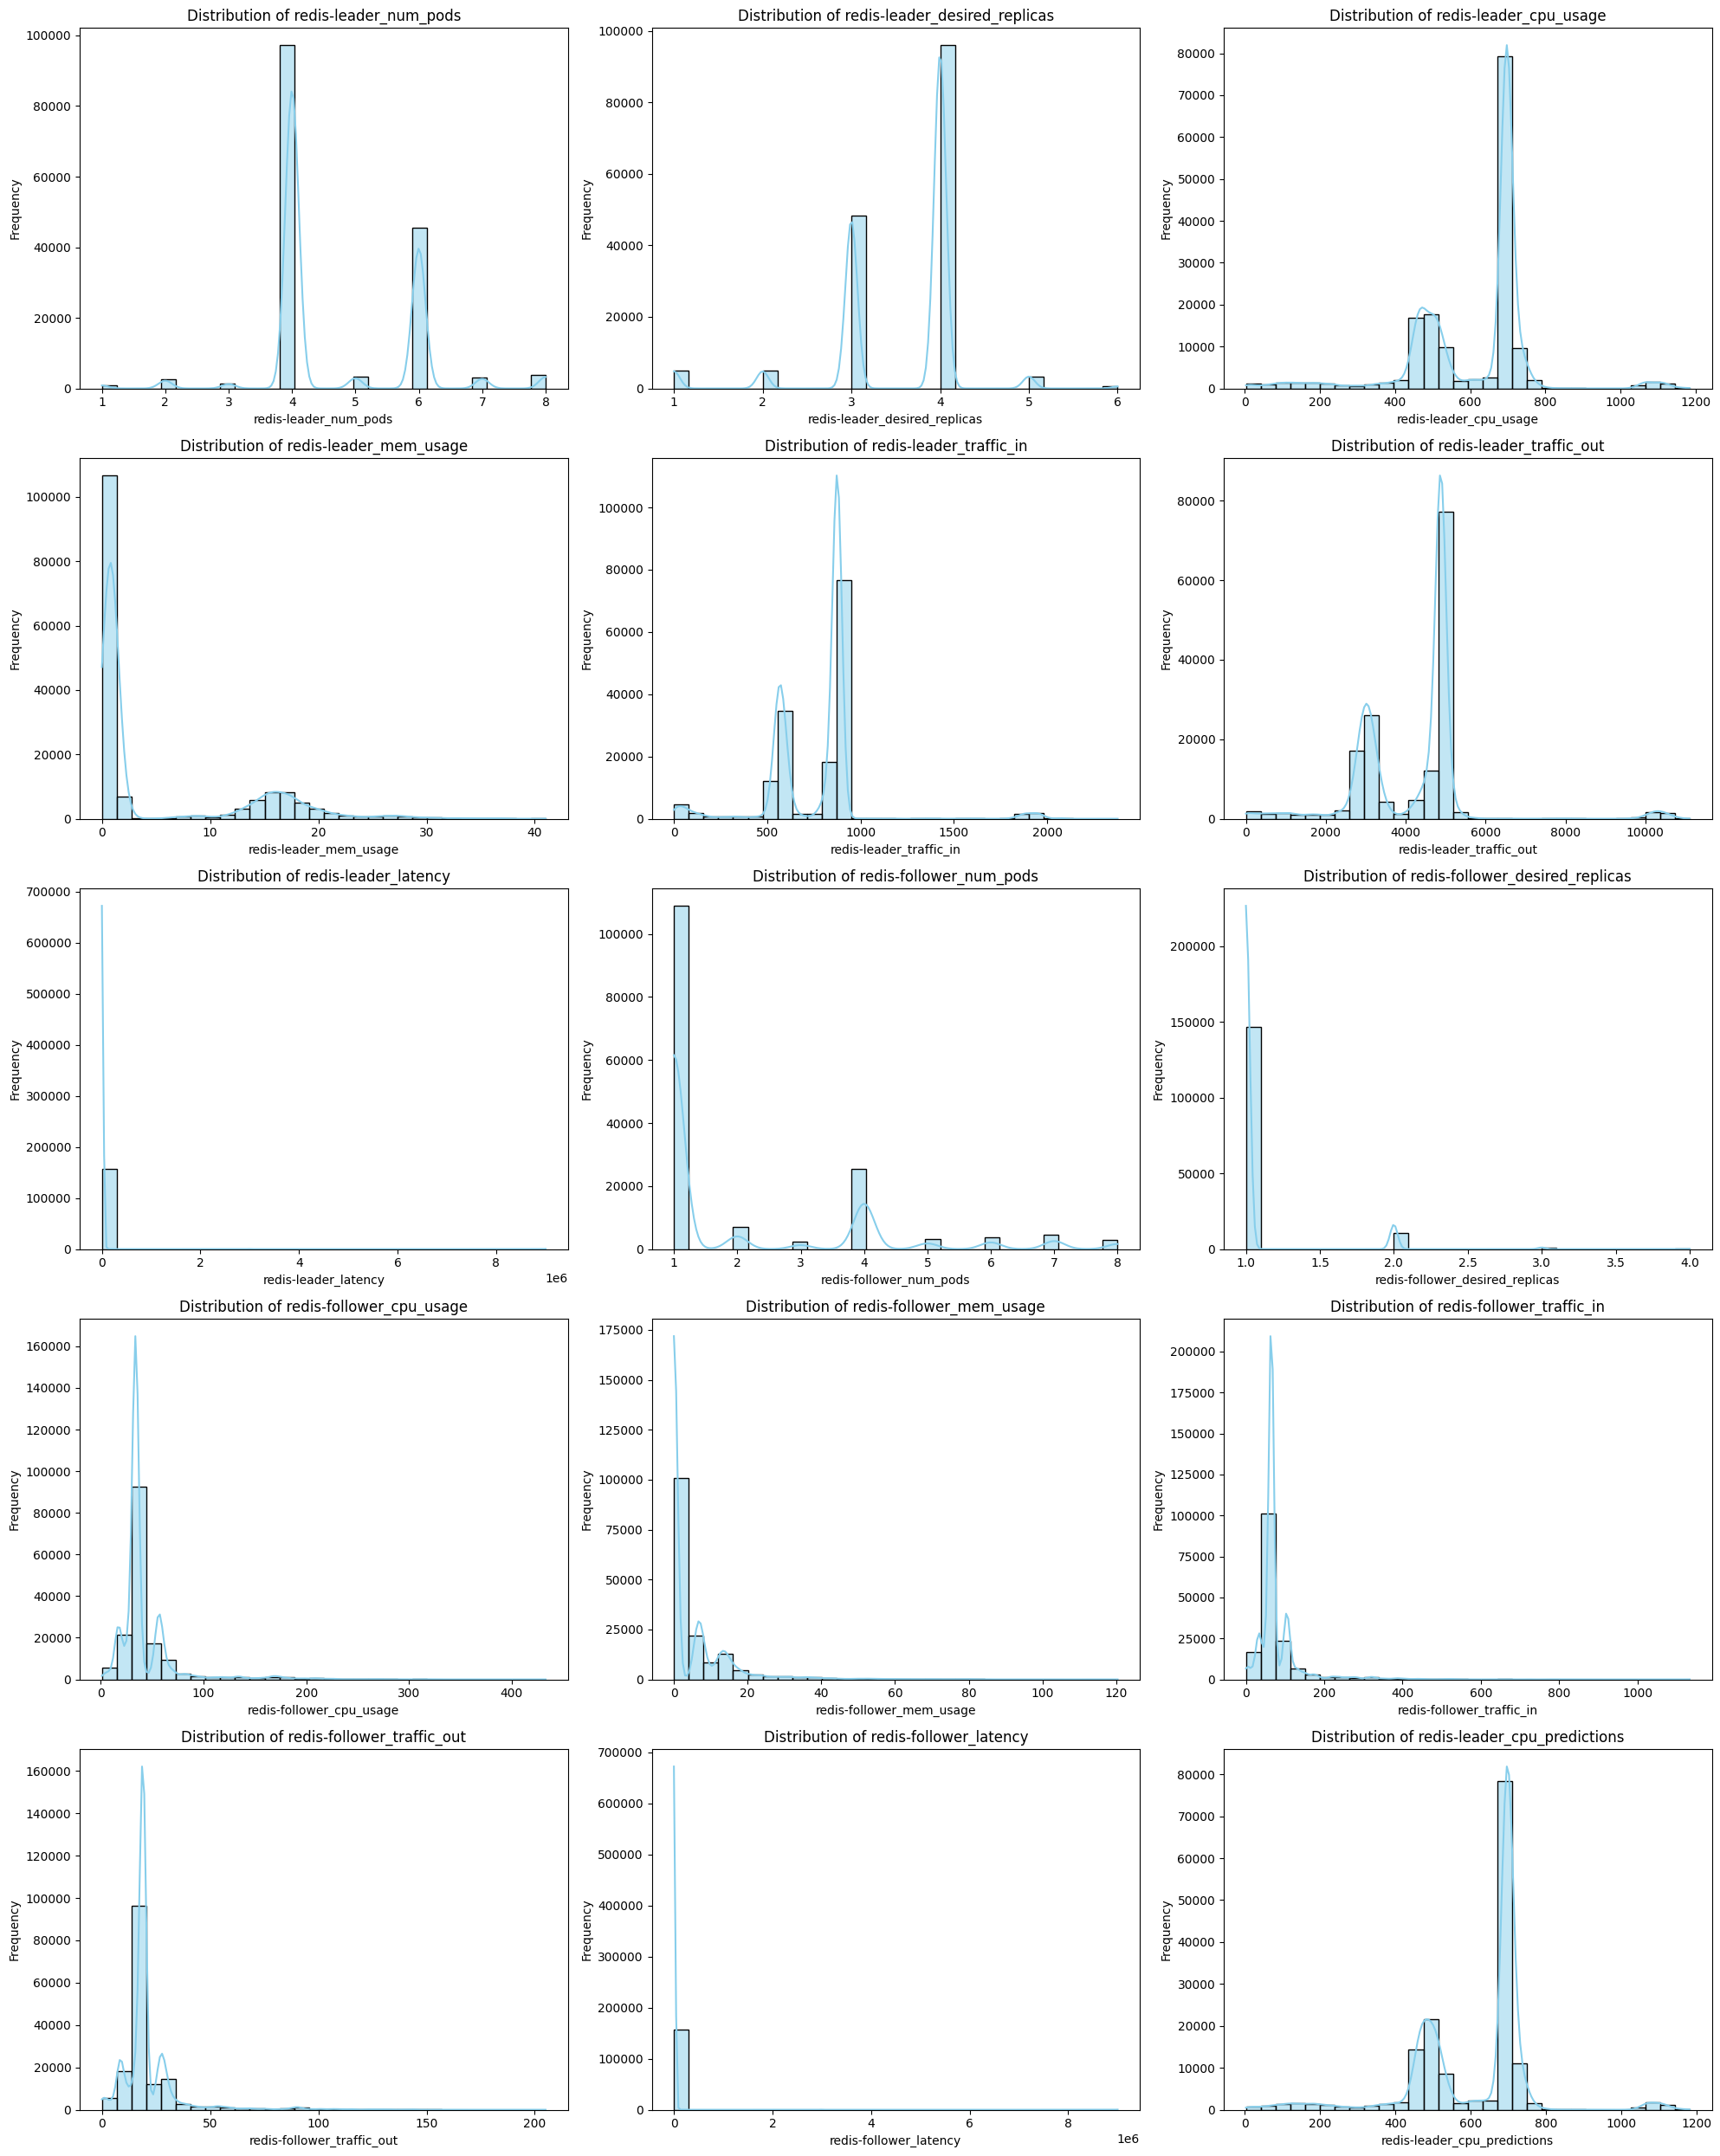

In [262]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

num_cols = 3
num_rows = (len(numerical_cols) + num_cols - 1) // num_cols

plt.figure(figsize=(20, 5 * num_rows))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(num_rows, num_cols, i)
    sns.histplot(df[col], bins=30, kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(f'{col}')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

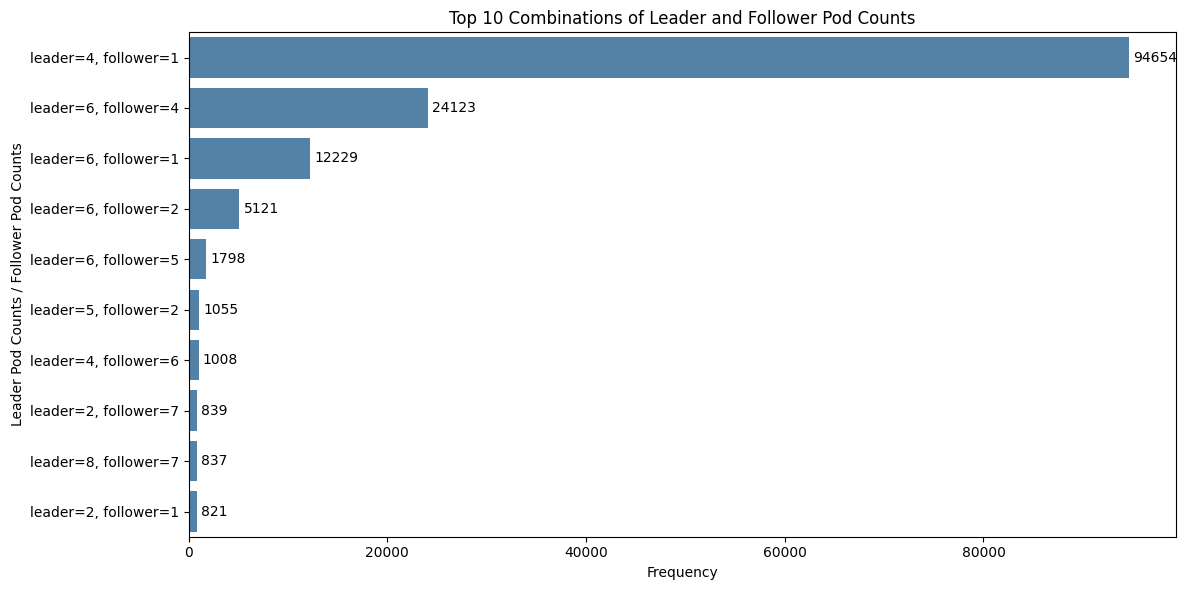

In [263]:
top_n = 10
combinations = df.groupby(['redis-leader_num_pods', 'redis-follower_num_pods']).size().reset_index(name='count') # should be 64 (8 x 8)
top_combinations = combinations.sort_values(by='count', ascending=False).head(top_n)

top_combinations['combination'] = "leader=" + top_combinations['redis-leader_num_pods'].astype(int).astype(str) + ", follower=" + top_combinations['redis-follower_num_pods'].astype(int).astype(str)

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top_combinations, x='count', y='combination', color='steelblue', legend=False)
plt.title(f'Top {top_n} Combinations of Leader and Follower Pod Counts')
plt.xlabel('Frequency')
plt.ylabel('Leader Pod Counts / Follower Pod Counts')

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

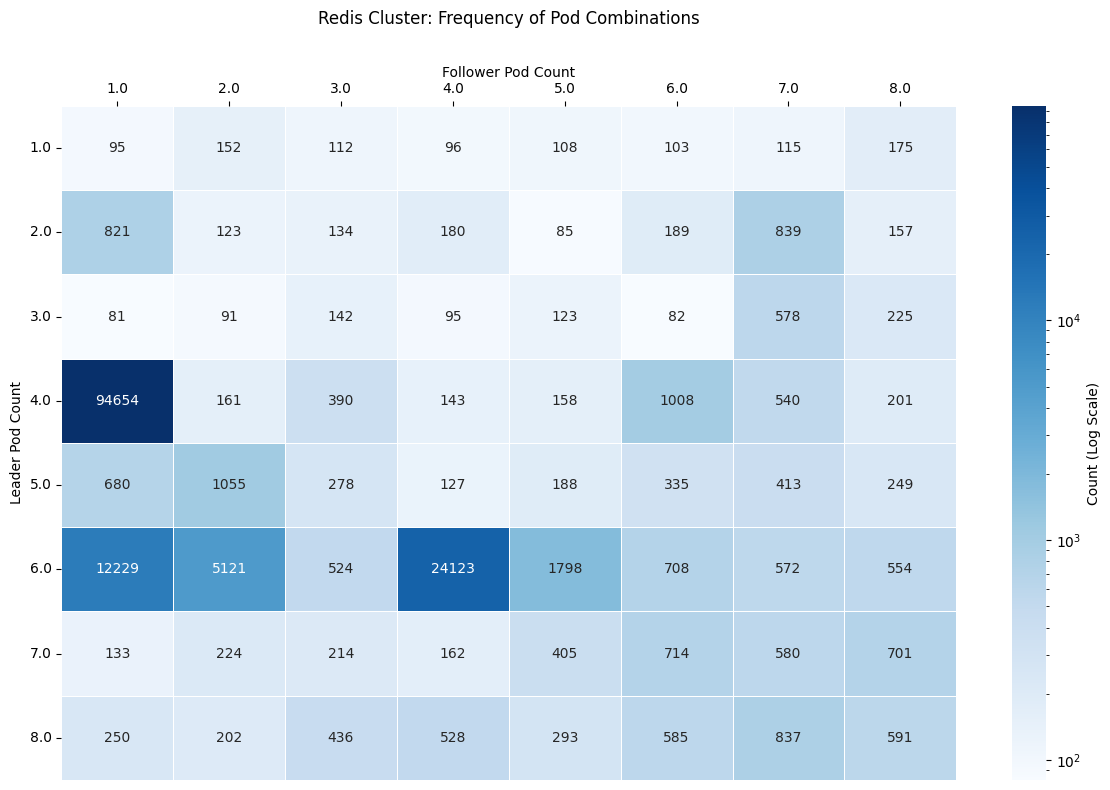

In [264]:
heatmap_data = pd.crosstab(df['redis-leader_num_pods'], df['redis-follower_num_pods'])
heatmap_data = heatmap_data.replace(0, np.nan)

plt.figure(figsize=(12, 8))

ax = sns.heatmap(heatmap_data, annot=True, fmt='g', cmap='Blues', norm=LogNorm(), linewidths=.5, cbar_kws={'label': 'Count (Log Scale)'})
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.title('Redis Cluster: Frequency of Pod Combinations', pad=30)
plt.ylabel('Leader Pod Count')
plt.xlabel('Follower Pod Count')

plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

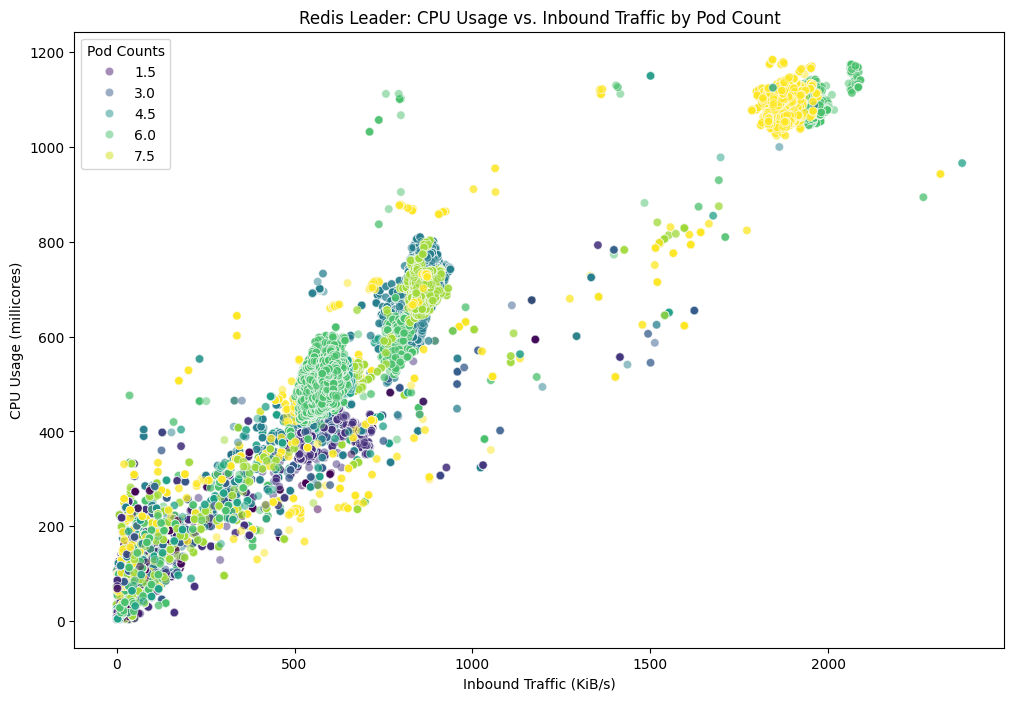

In [265]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='redis-leader_traffic_in', y='redis-leader_cpu_usage', hue='redis-leader_num_pods', palette='viridis', alpha=0.5)
plt.title('Redis Leader: CPU Usage vs. Inbound Traffic by Pod Count')
plt.xlabel('Inbound Traffic (KiB/s)')
plt.ylabel('CPU Usage (millicores)')
plt.legend(title='Pod Counts')
plt.show()

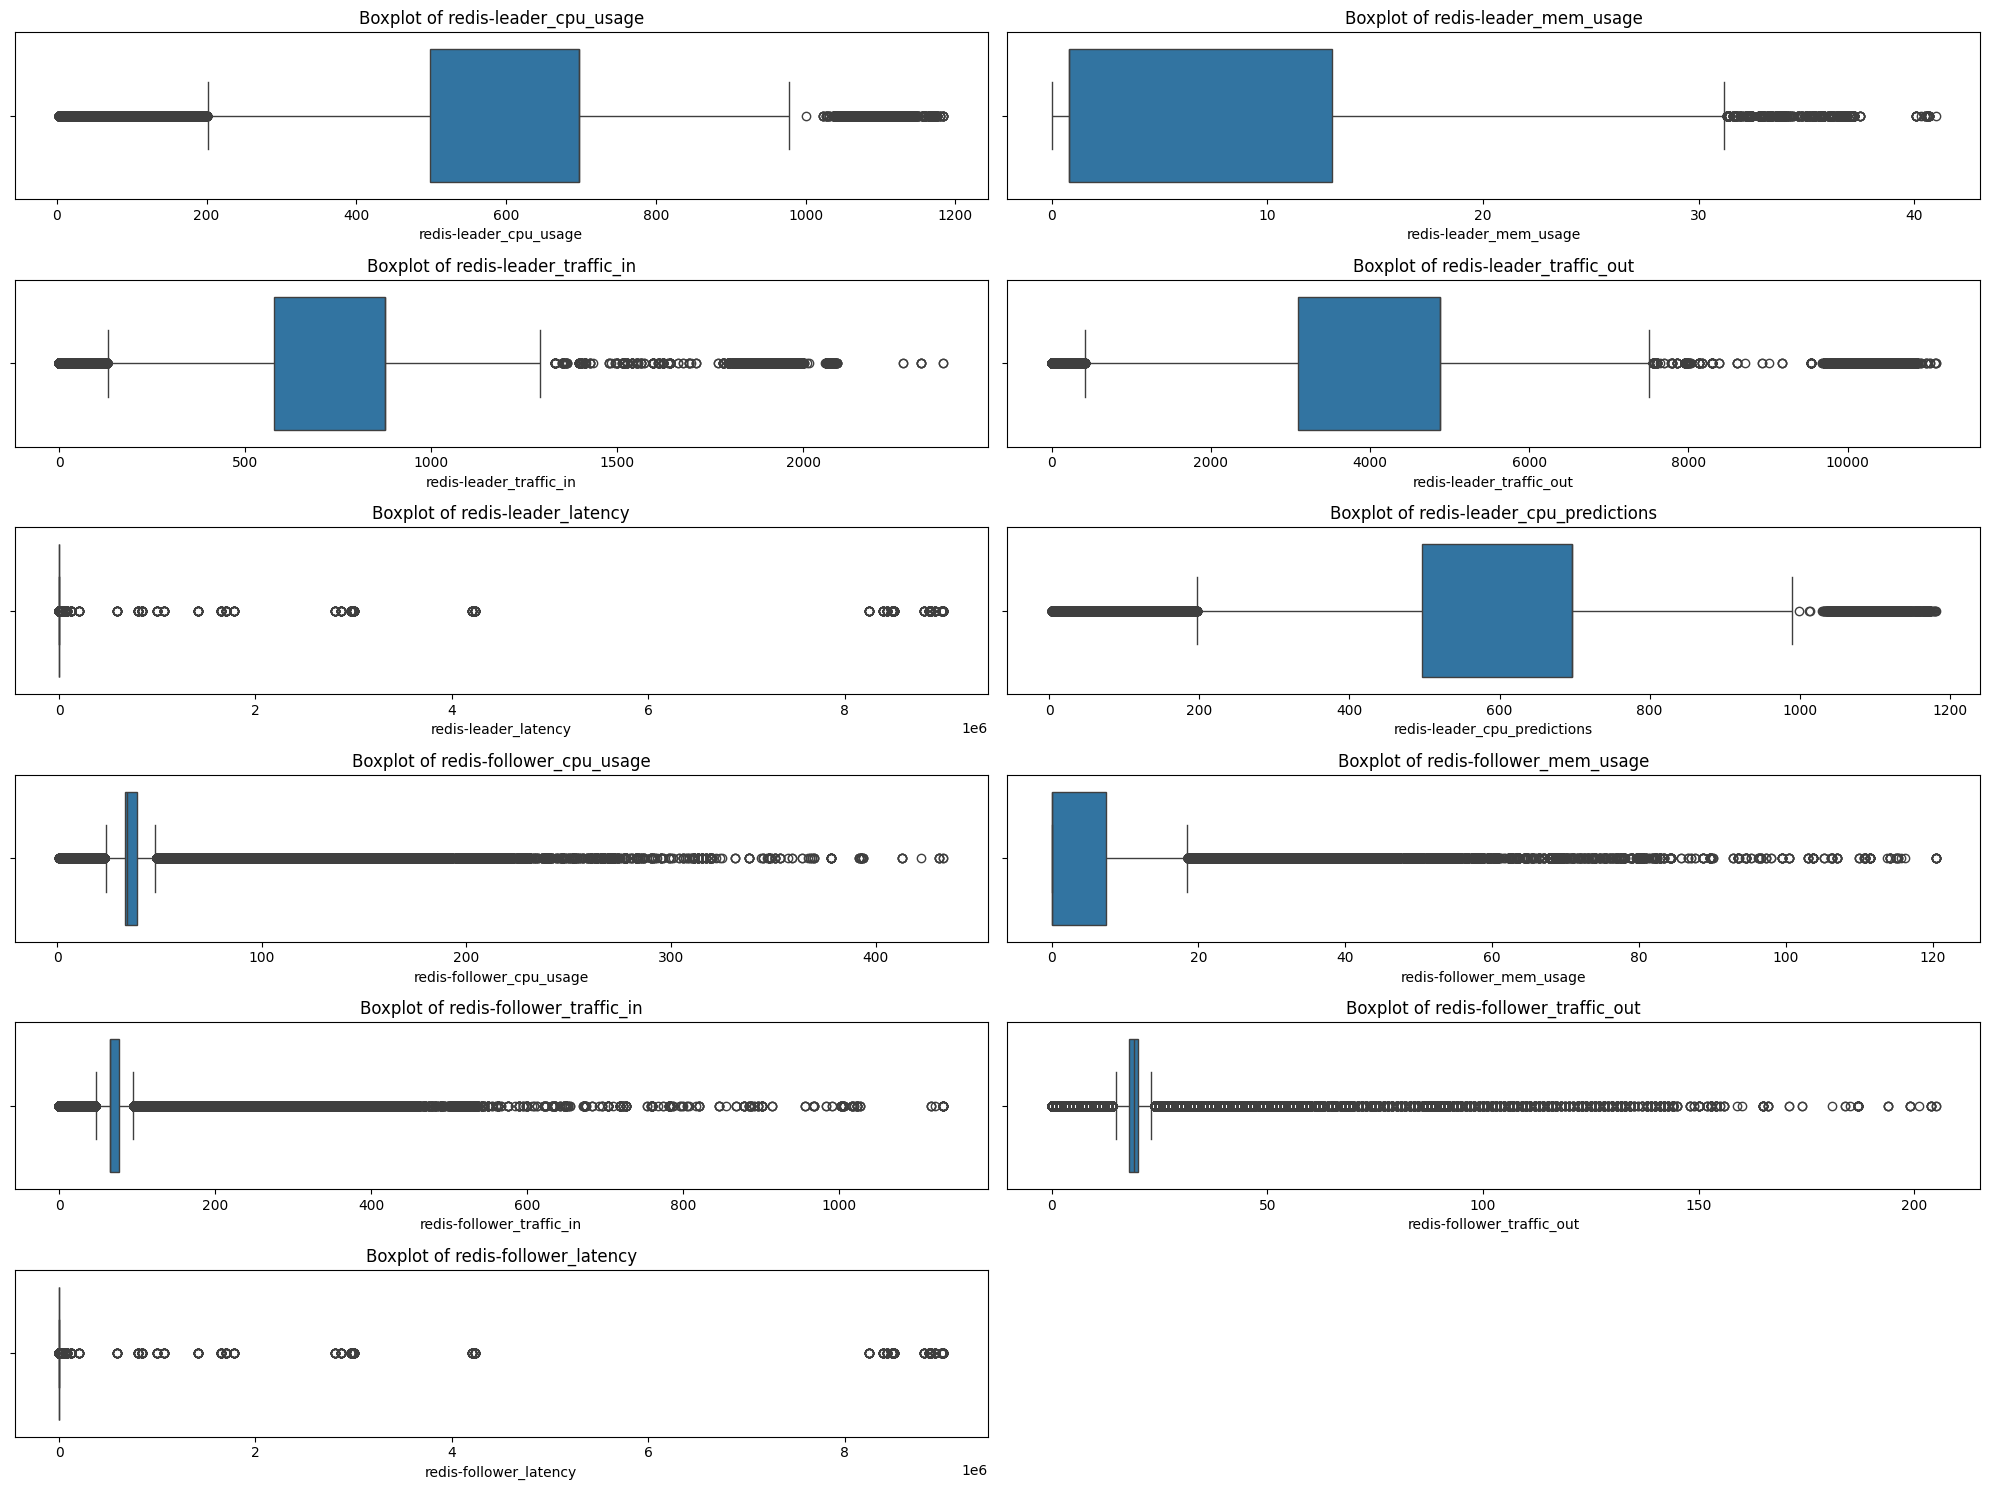

In [266]:
# List of numerical continuous columns
columns_to_plot = [
    'redis-leader_cpu_usage', 'redis-leader_mem_usage',
    'redis-leader_traffic_in', 'redis-leader_traffic_out',
    'redis-leader_latency', 'redis-leader_cpu_predictions',
    'redis-follower_cpu_usage', 'redis-follower_mem_usage',
    'redis-follower_traffic_in', 'redis-follower_traffic_out',
    'redis-follower_latency'
]

# Create a figure with subplots
plt.figure(figsize=(20, 15))
for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(6, 2, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

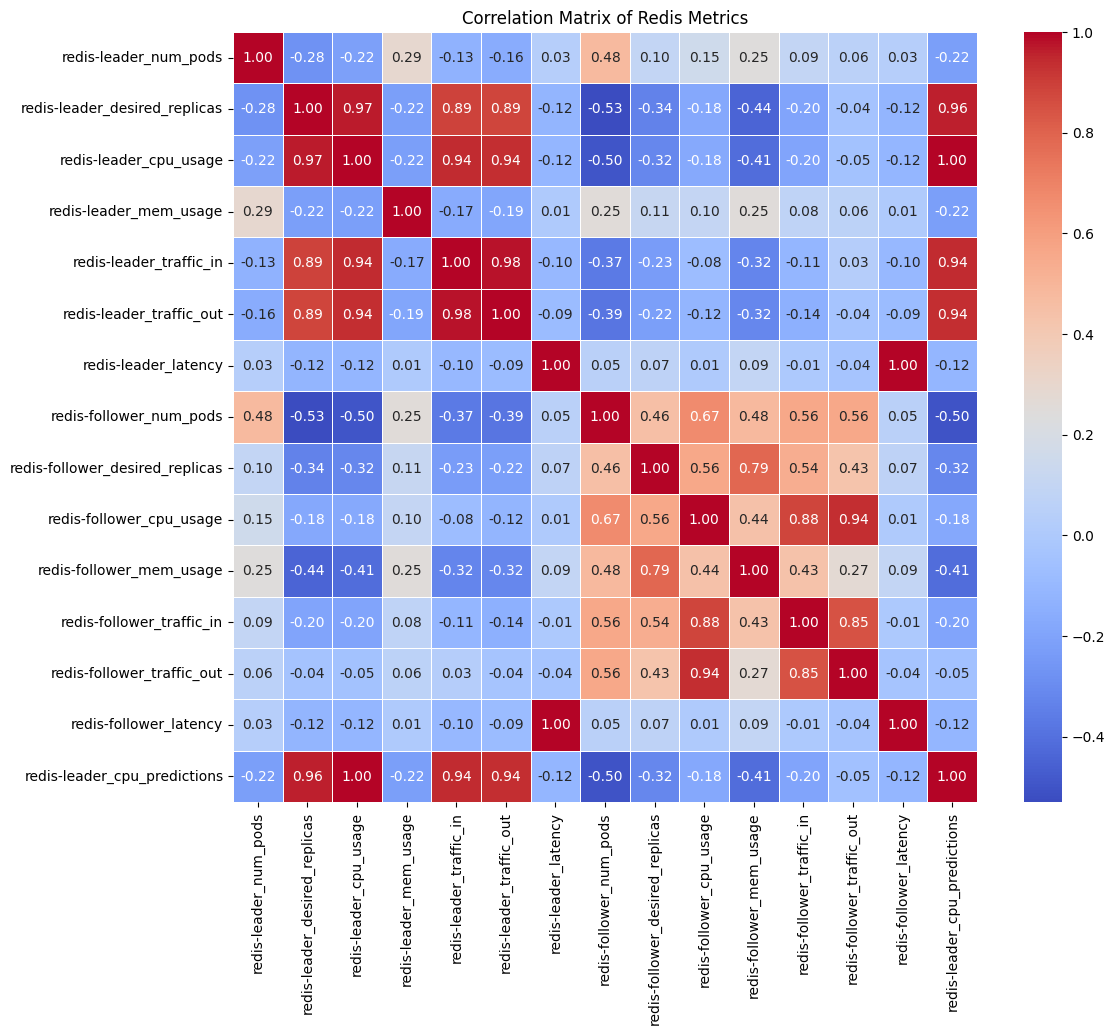

In [267]:
plt.figure(figsize=(12, 10))
corr_matrix = df.select_dtypes(include=[np.number]).corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Redis Metrics')
plt.show()

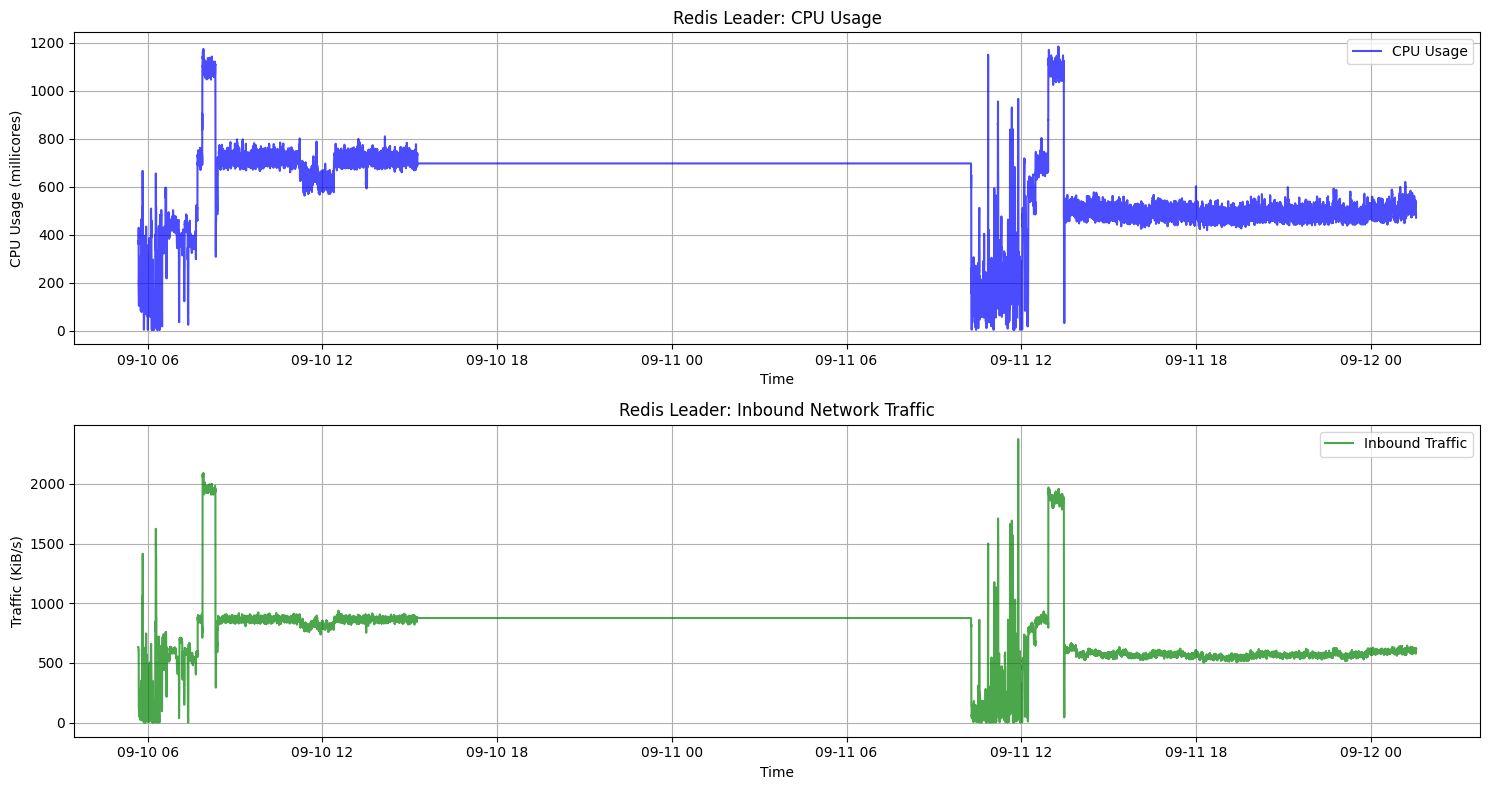

In [268]:
# Plotting CPU usage and Traffic over time
plt.figure(figsize=(15, 8))

plt.subplot(2, 1, 1)
plt.plot(df_time.index, df_time['redis-leader_cpu_usage'], label='CPU Usage', color='blue', alpha=0.7)
plt.title('Redis Leader: CPU Usage')
plt.xlabel('Time')
plt.ylabel('CPU Usage (millicores)')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(df_time.index, df_time['redis-leader_traffic_in'], label='Inbound Traffic', color='green', alpha=0.7)
plt.title('Redis Leader: Inbound Network Traffic')
plt.xlabel('Time')
plt.ylabel('Traffic (KiB/s)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

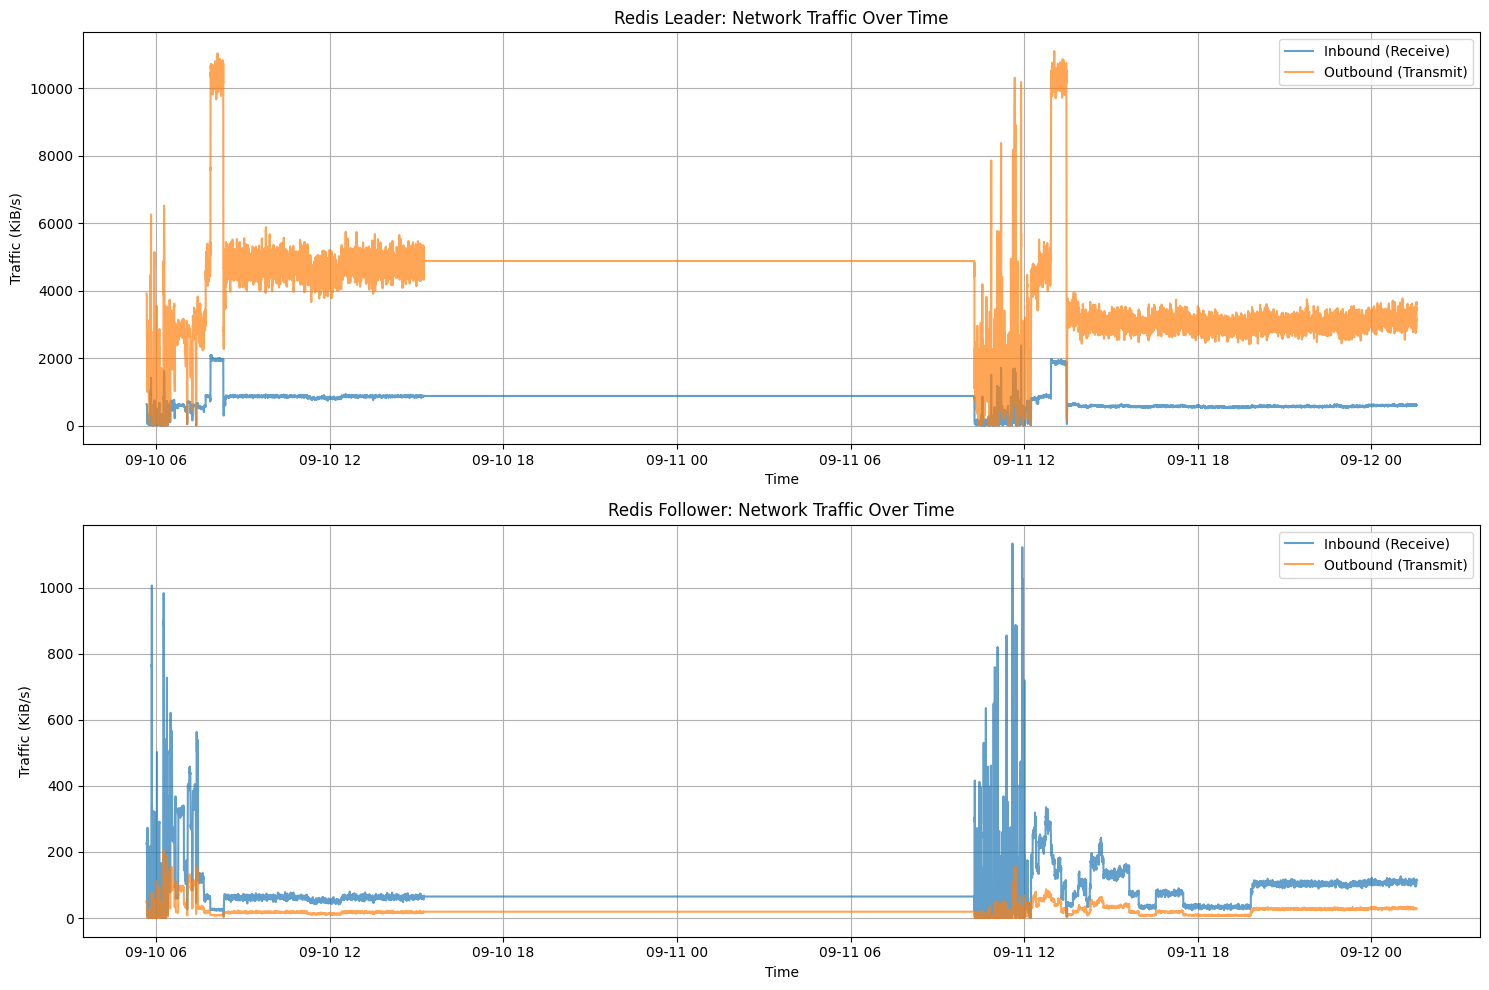

In [269]:
# Comparison of Traffic In vs Traffic Out for Redis Leader and Follower
plt.figure(figsize=(15, 10))

# Leader Traffic
plt.subplot(2, 1, 1)
plt.plot(df_time.index, df_time['redis-leader_traffic_in'], label='Inbound (Receive)', color='tab:blue', alpha=0.7)
plt.plot(df_time.index, df_time['redis-leader_traffic_out'], label='Outbound (Transmit)', color='tab:orange', alpha=0.7)
plt.title('Redis Leader: Network Traffic Over Time')
plt.ylabel('Traffic (KiB/s)')
plt.xlabel('Time')
plt.legend()
plt.grid(True)

# Follower Traffic
plt.subplot(2, 1, 2)
plt.plot(df_time.index, df_time['redis-follower_traffic_in'], label='Inbound (Receive)', color='tab:blue', alpha=0.7)
plt.plot(df_time.index, df_time['redis-follower_traffic_out'], label='Outbound (Transmit)', color='tab:orange', alpha=0.7)
plt.title('Redis Follower: Network Traffic Over Time')
plt.ylabel('Traffic (KiB/s)')
plt.xlabel('Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

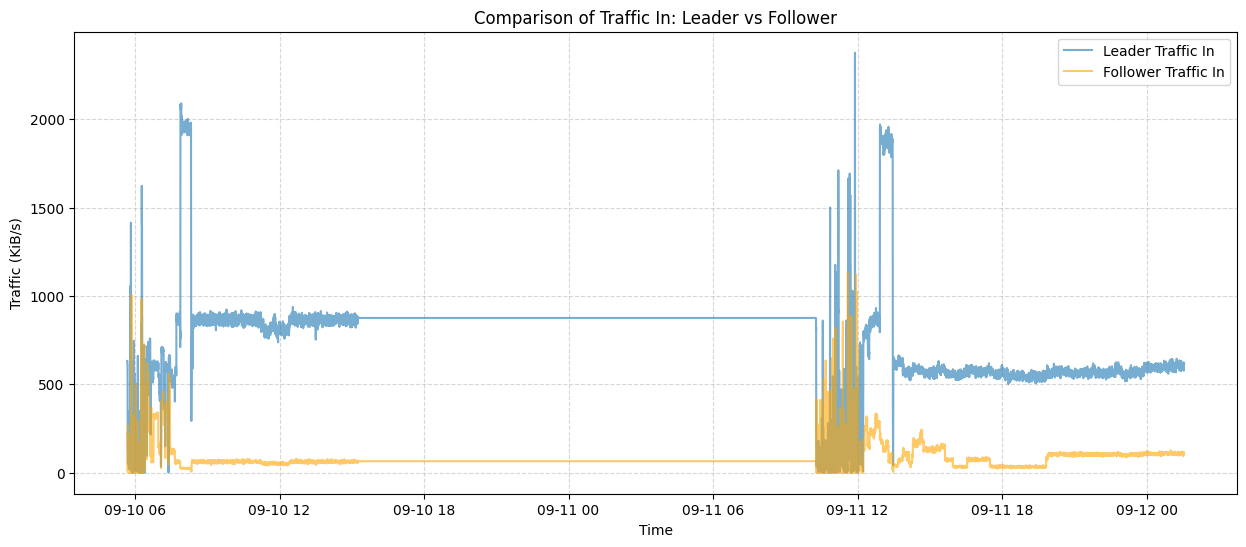

In [270]:
plt.figure(figsize=(15, 6))
plt.plot(df_time.index, df_time['redis-leader_traffic_in'], label='Leader Traffic In', alpha=0.6)
plt.plot(df_time.index, df_time['redis-follower_traffic_in'], label='Follower Traffic In', alpha=0.6, color='orange')

plt.title('Comparison of Traffic In: Leader vs Follower')
plt.xlabel('Time')
plt.ylabel('Traffic (KiB/s)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

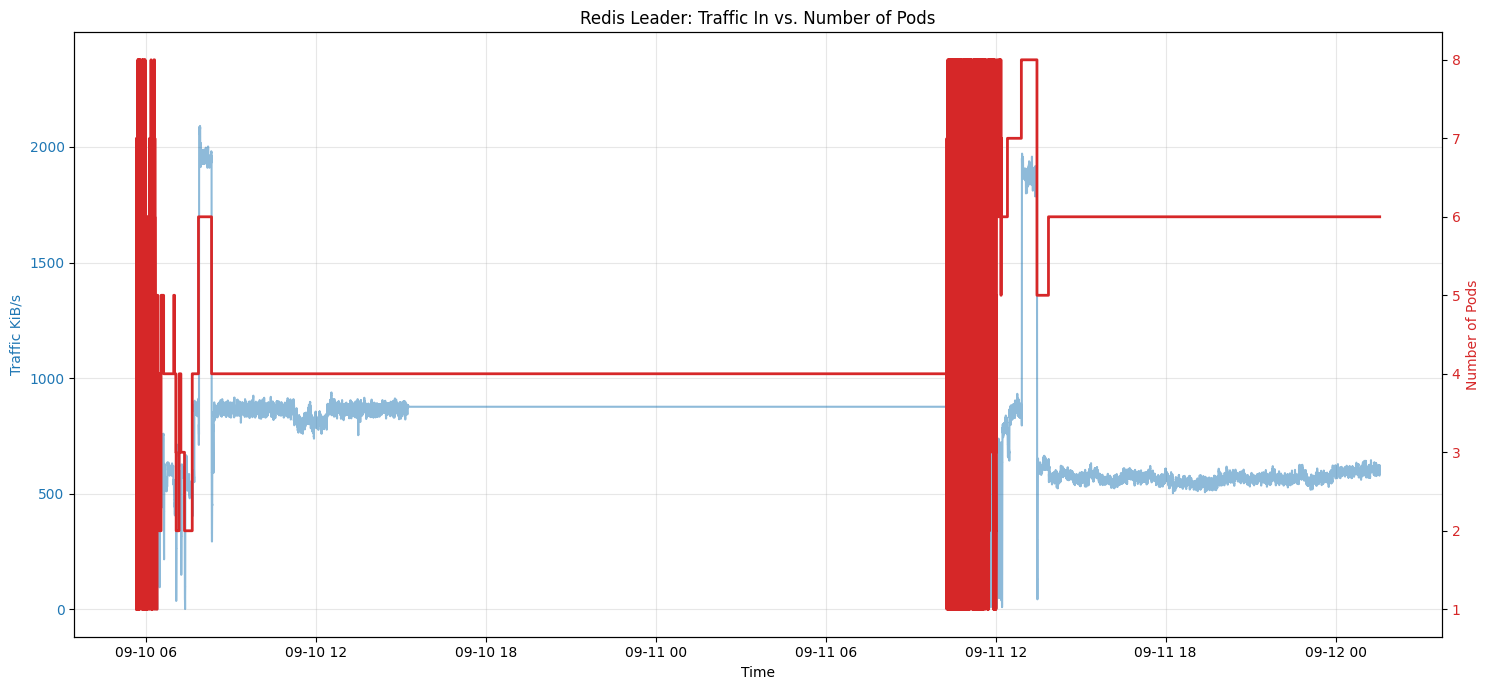

In [271]:
fig, ax1 = plt.subplots(figsize=(15, 7))

color = 'tab:blue'
ax1.set_xlabel('Time')
ax1.set_ylabel('Traffic KiB/s', color=color)
ax1.plot(df_time.index, df_time['redis-leader_traffic_in'], color=color, alpha=0.5, label='Traffic In')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Number of Pods', color=color)
ax2.step(df_time.index, df_time['redis-leader_num_pods'], color=color, where='post', linewidth=2, label='Leader Pods')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Redis Leader: Traffic In vs. Number of Pods')
fig.tight_layout()
plt.show()

## Preprocessing

Number of outliers in redis-leader_latency: 24853
Percentage of dataset: 15.73%


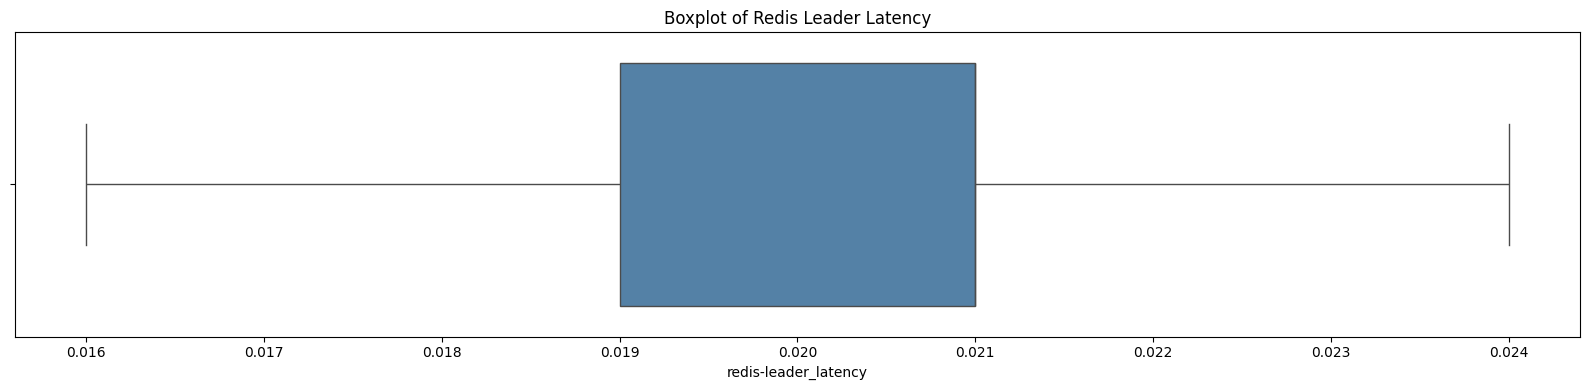

In [272]:
# We'll be using `redis-leader_latency`, since it's the same as `readis-follower_latency`
Q1 = df['redis-leader_latency'].quantile(0.25)
Q3 = df['redis-leader_latency'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count the outliers
outliers = df[(df['redis-leader_latency'] < lower_bound) | (df['redis-leader_latency'] > upper_bound)]
print(f"Number of outliers in redis-leader_latency: {len(outliers)}")
print(f"Percentage of dataset: {(len(outliers) / len(df)) * 100:.2f}%")

clean_data = df[(df['redis-leader_latency'] >= lower_bound) & (df['redis-leader_latency'] <= upper_bound)]
fig, ax = plt.subplots(figsize=(16, 4))
sns.boxplot(x=clean_data['redis-leader_latency'], color='steelblue', ax=ax)
ax.set(title='Boxplot of Redis Leader Latency')
plt.tight_layout()
plt.show()

In [273]:
df.loc[df['redis-leader_latency'] > upper_bound, 'redis-leader_latency'] = np.nan
df.loc[df['redis-follower_latency'] > upper_bound, 'redis-follower_latency'] = np.nan

In [274]:
df['redis-leader_latency'] = df['redis-leader_latency'].interpolate(method='linear')
df['redis-follower_latency'] = df['redis-follower_latency'].interpolate(method='linear')

In [275]:
df['redis-leader_latency'] = df['redis-leader_latency'].bfill().ffill()
df['redis-follower_latency'] = df['redis-follower_latency'].bfill().ffill()

In [276]:
df['redis-leader_latency'] = df['redis-leader_latency'].round(3)
df['redis-follower_latency'] = df['redis-follower_latency'].round(3)

In [277]:
print("Check for NaNs:")
print(df[['redis-leader_latency', 'redis-follower_latency']].isna().sum())

Check for NaNs:
redis-leader_latency      0
redis-follower_latency    0
dtype: int64


In [278]:
df.to_csv('redis_gym_observation_corrected_v2.csv', index=False)